In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from imblearn.over_sampling import SMOTE 
import optuna
from sklearn.metrics import accuracy_score, precision_score, f1_score, r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

from sklearn.ensemble import BaggingRegressor, BaggingClassifier, GradientBoostingRegressor, GradientBoostingClassifier, StackingRegressor, StackingClassifier

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

from xgboost import XGBClassifier, XGBRegressor

from lightgbm import LGBMClassifier, LGBMRegressor

from catboost import CatBoostClassifier, CatBoostRegressor

RANDOM_STATE = 42

class_cv = StratifiedKFold(5, shuffle = True, random_state = RANDOM_STATE)
reg_cv = KFold(5, shuffle = True, random_state = RANDOM_STATE)

**Загрузка датасетов**

In [4]:
class_df = pd.read_csv("../csv/cl_finished.csv", sep = ";")
X_class = class_df.drop(columns = "Diabetes_012")
y_class = class_df["Diabetes_012"]

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(X_class, y_class, test_size = 0.3, stratify = y_class, random_state = RANDOM_STATE)

In [5]:
regress_df = pd.read_csv("../csv/winequality_finished.csv", sep = ";")
X_reg = regress_df.drop(columns = "quality")
y_reg = regress_df["quality"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size = 0.3, random_state = RANDOM_STATE)

**Модели решающих деревьев**

In [6]:

def objective_trees(trial, model_type):
    if model_type == "classification":
        max_depth = trial.suggest_int("max_depth", 2, 64)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 32)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 32)

        criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])

        model = DecisionTreeClassifier(max_depth = max_depth, min_samples_split = min_samples_split, 
                                            min_samples_leaf = min_samples_leaf, criterion = criterion, random_state = RANDOM_STATE)
        
        score = cross_val_score(model, X_class_train, y_class_train, cv=class_cv, scoring="accuracy").mean()
        
        return score

    
    if model_type == "regression":

        max_depth = trial.suggest_int("max_depth", 2, 64)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 16)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 16)

        criterion = trial.suggest_categorical("criterion", ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'])

        model = DecisionTreeRegressor(max_depth = max_depth, min_samples_split = min_samples_split, 
                                            min_samples_leaf = min_samples_leaf, criterion = criterion, random_state = RANDOM_STATE)

        score = cross_val_score(model, X_reg_train, y_reg_train, cv = reg_cv, scoring = "neg_mean_squared_error").mean()

        return score

In [30]:
study_class = optuna.create_study(direction = "maximize")
study_class.optimize(lambda trial: objective_trees(trial, "classification"), n_trials = 25)

best_class_tree_model = DecisionTreeClassifier(**study_class.best_params, random_state = RANDOM_STATE)
best_class_tree_model.fit(X_class_train, y_class_train)

[I 2026-05-23 12:52:59,884] A new study created in memory with name: no-name-7797168b-de38-4116-8929-996621d12385
[I 2026-05-23 12:53:01,127] Trial 0 finished with value: 0.8322432574167553 and parameters: {'max_depth': 6, 'min_samples_split': 20, 'min_samples_leaf': 18, 'criterion': 'log_loss'}. Best is trial 0 with value: 0.8322432574167553.
[I 2026-05-23 12:53:03,672] Trial 1 finished with value: 0.8067032938309474 and parameters: {'max_depth': 34, 'min_samples_split': 22, 'min_samples_leaf': 3, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8322432574167553.
[I 2026-05-23 12:53:05,622] Trial 2 finished with value: 0.8267410996863365 and parameters: {'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 7, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8322432574167553.
[I 2026-05-23 12:53:07,671] Trial 3 finished with value: 0.8286062433735465 and parameters: {'max_depth': 13, 'min_samples_split': 19, 'min_samples_leaf': 23, 'criterion': 'log_loss'}. Best is

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'log_loss'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",18
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [31]:
pred = best_class_tree_model.predict(X_class_test)
print(f"Accuracy: {accuracy_score(y_class_test, pred)}")
print(f"Precision: {precision_score(y_class_test, pred, average = 'weighted')}")
print(f"F1 score: {f1_score(y_class_test, pred, average = 'weighted')}")

Accuracy: 0.8337564372234714
Precision: 0.785170013706016
F1 score: 0.784713536118605


C:\Users\Chaizee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


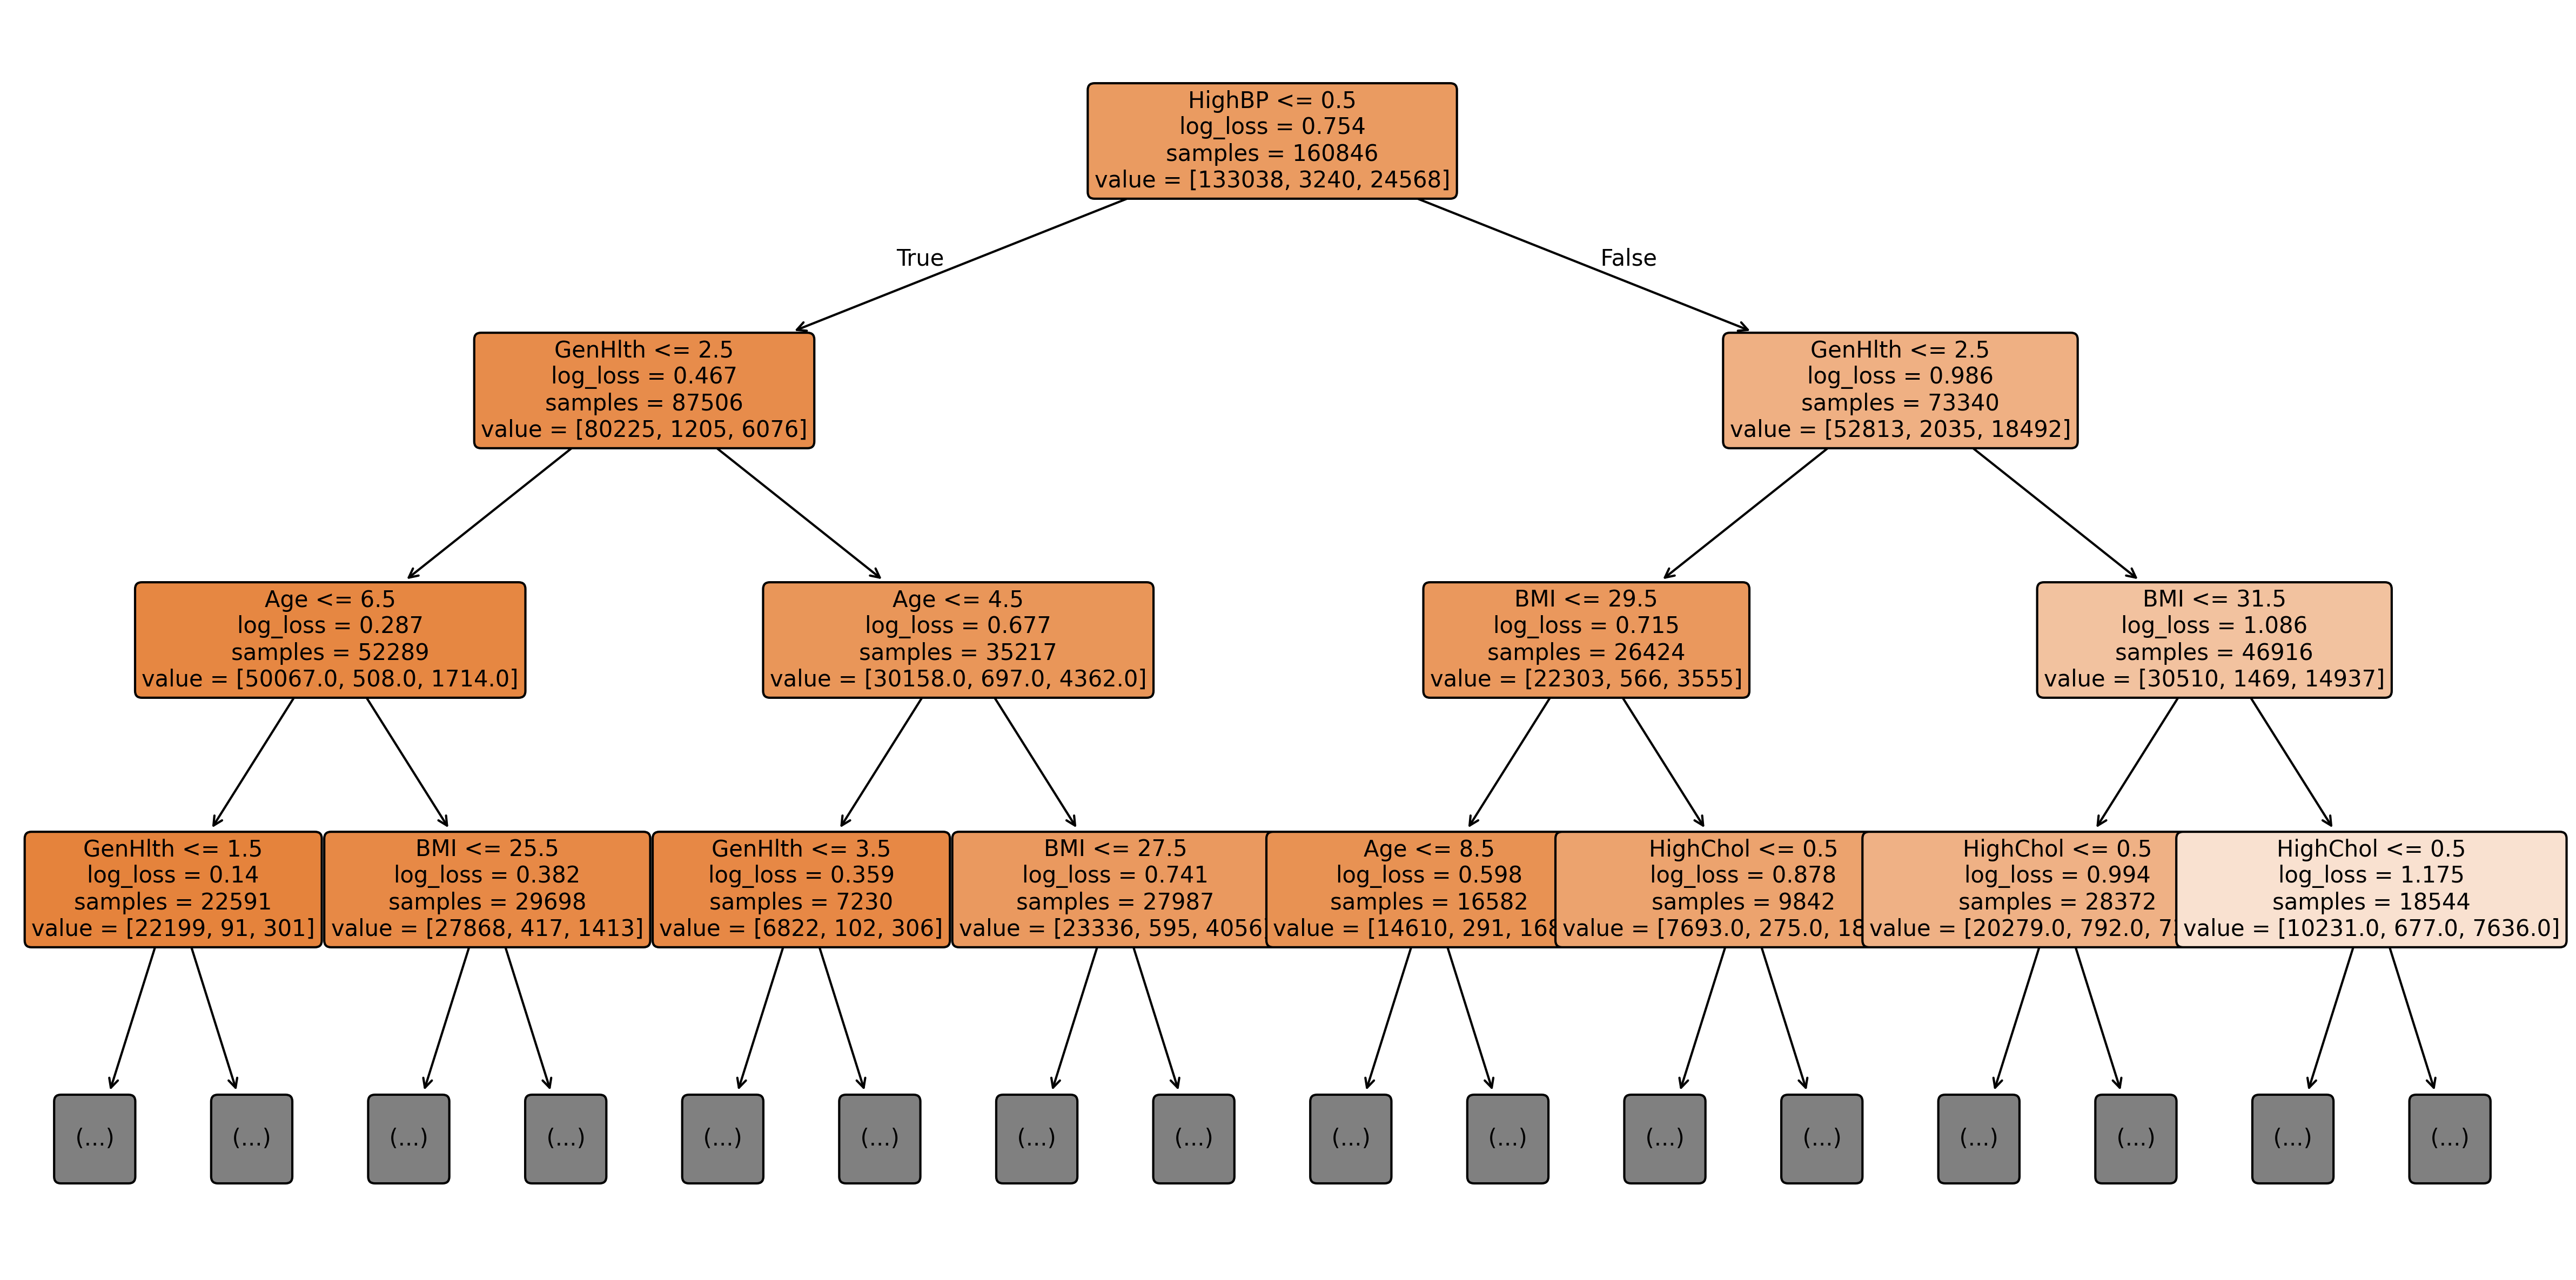

In [32]:
plt.figure(figsize=(20, 10), dpi=300)

plot_tree(
    best_class_tree_model,
    max_depth=3,
    feature_names=X_class.columns,
    filled=True,
    rounded=True,
    fontsize=10,
)

plt.show()

In [33]:
study_reg = optuna.create_study(direction = "maximize")
study_reg.optimize(lambda trial: objective_trees(trial, "regression"), n_trials = 100)

best_reg_tree_model = DecisionTreeRegressor(**study_reg.best_params, random_state = RANDOM_STATE)
best_reg_tree_model.fit(X_reg_train, y_reg_train)

[I 2026-05-23 12:53:46,812] A new study created in memory with name: no-name-f26505da-85d9-401a-b991-f9055751a6c7
[I 2026-05-23 12:53:46,915] Trial 0 finished with value: -0.5660136545369627 and parameters: {'max_depth': 59, 'min_samples_split': 13, 'min_samples_leaf': 16, 'criterion': 'poisson'}. Best is trial 0 with value: -0.5660136545369627.
[I 2026-05-23 12:53:47,030] Trial 1 finished with value: -0.654023445572735 and parameters: {'max_depth': 26, 'min_samples_split': 8, 'min_samples_leaf': 4, 'criterion': 'squared_error'}. Best is trial 0 with value: -0.5660136545369627.
[I 2026-05-23 12:53:47,137] Trial 2 finished with value: -0.5666421507112076 and parameters: {'max_depth': 14, 'min_samples_split': 9, 'min_samples_leaf': 14, 'criterion': 'poisson'}. Best is trial 0 with value: -0.5660136545369627.
[I 2026-05-23 12:53:47,257] Trial 3 finished with value: -0.6630307969388883 and parameters: {'max_depth': 49, 'min_samples_split': 10, 'min_samples_leaf': 3, 'criterion': 'squared_e

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'friedman_mse'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",16
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [34]:
pred_reg = best_reg_tree_model.predict(X_reg_test)

print(f"R2: {r2_score(y_reg_test, pred_reg)}")
print(f"MSE: {mean_squared_error(y_reg_test, pred_reg)}")
print(f"MAE: {mean_absolute_error(y_reg_test, pred_reg)}")
print(f"MAPE: {mean_absolute_percentage_error(y_reg_test, pred_reg)}")

R2: 0.2740367235636497
MSE: 0.5296918259272821
MAE: 0.563158058243038
MAPE: 0.10114731741023243


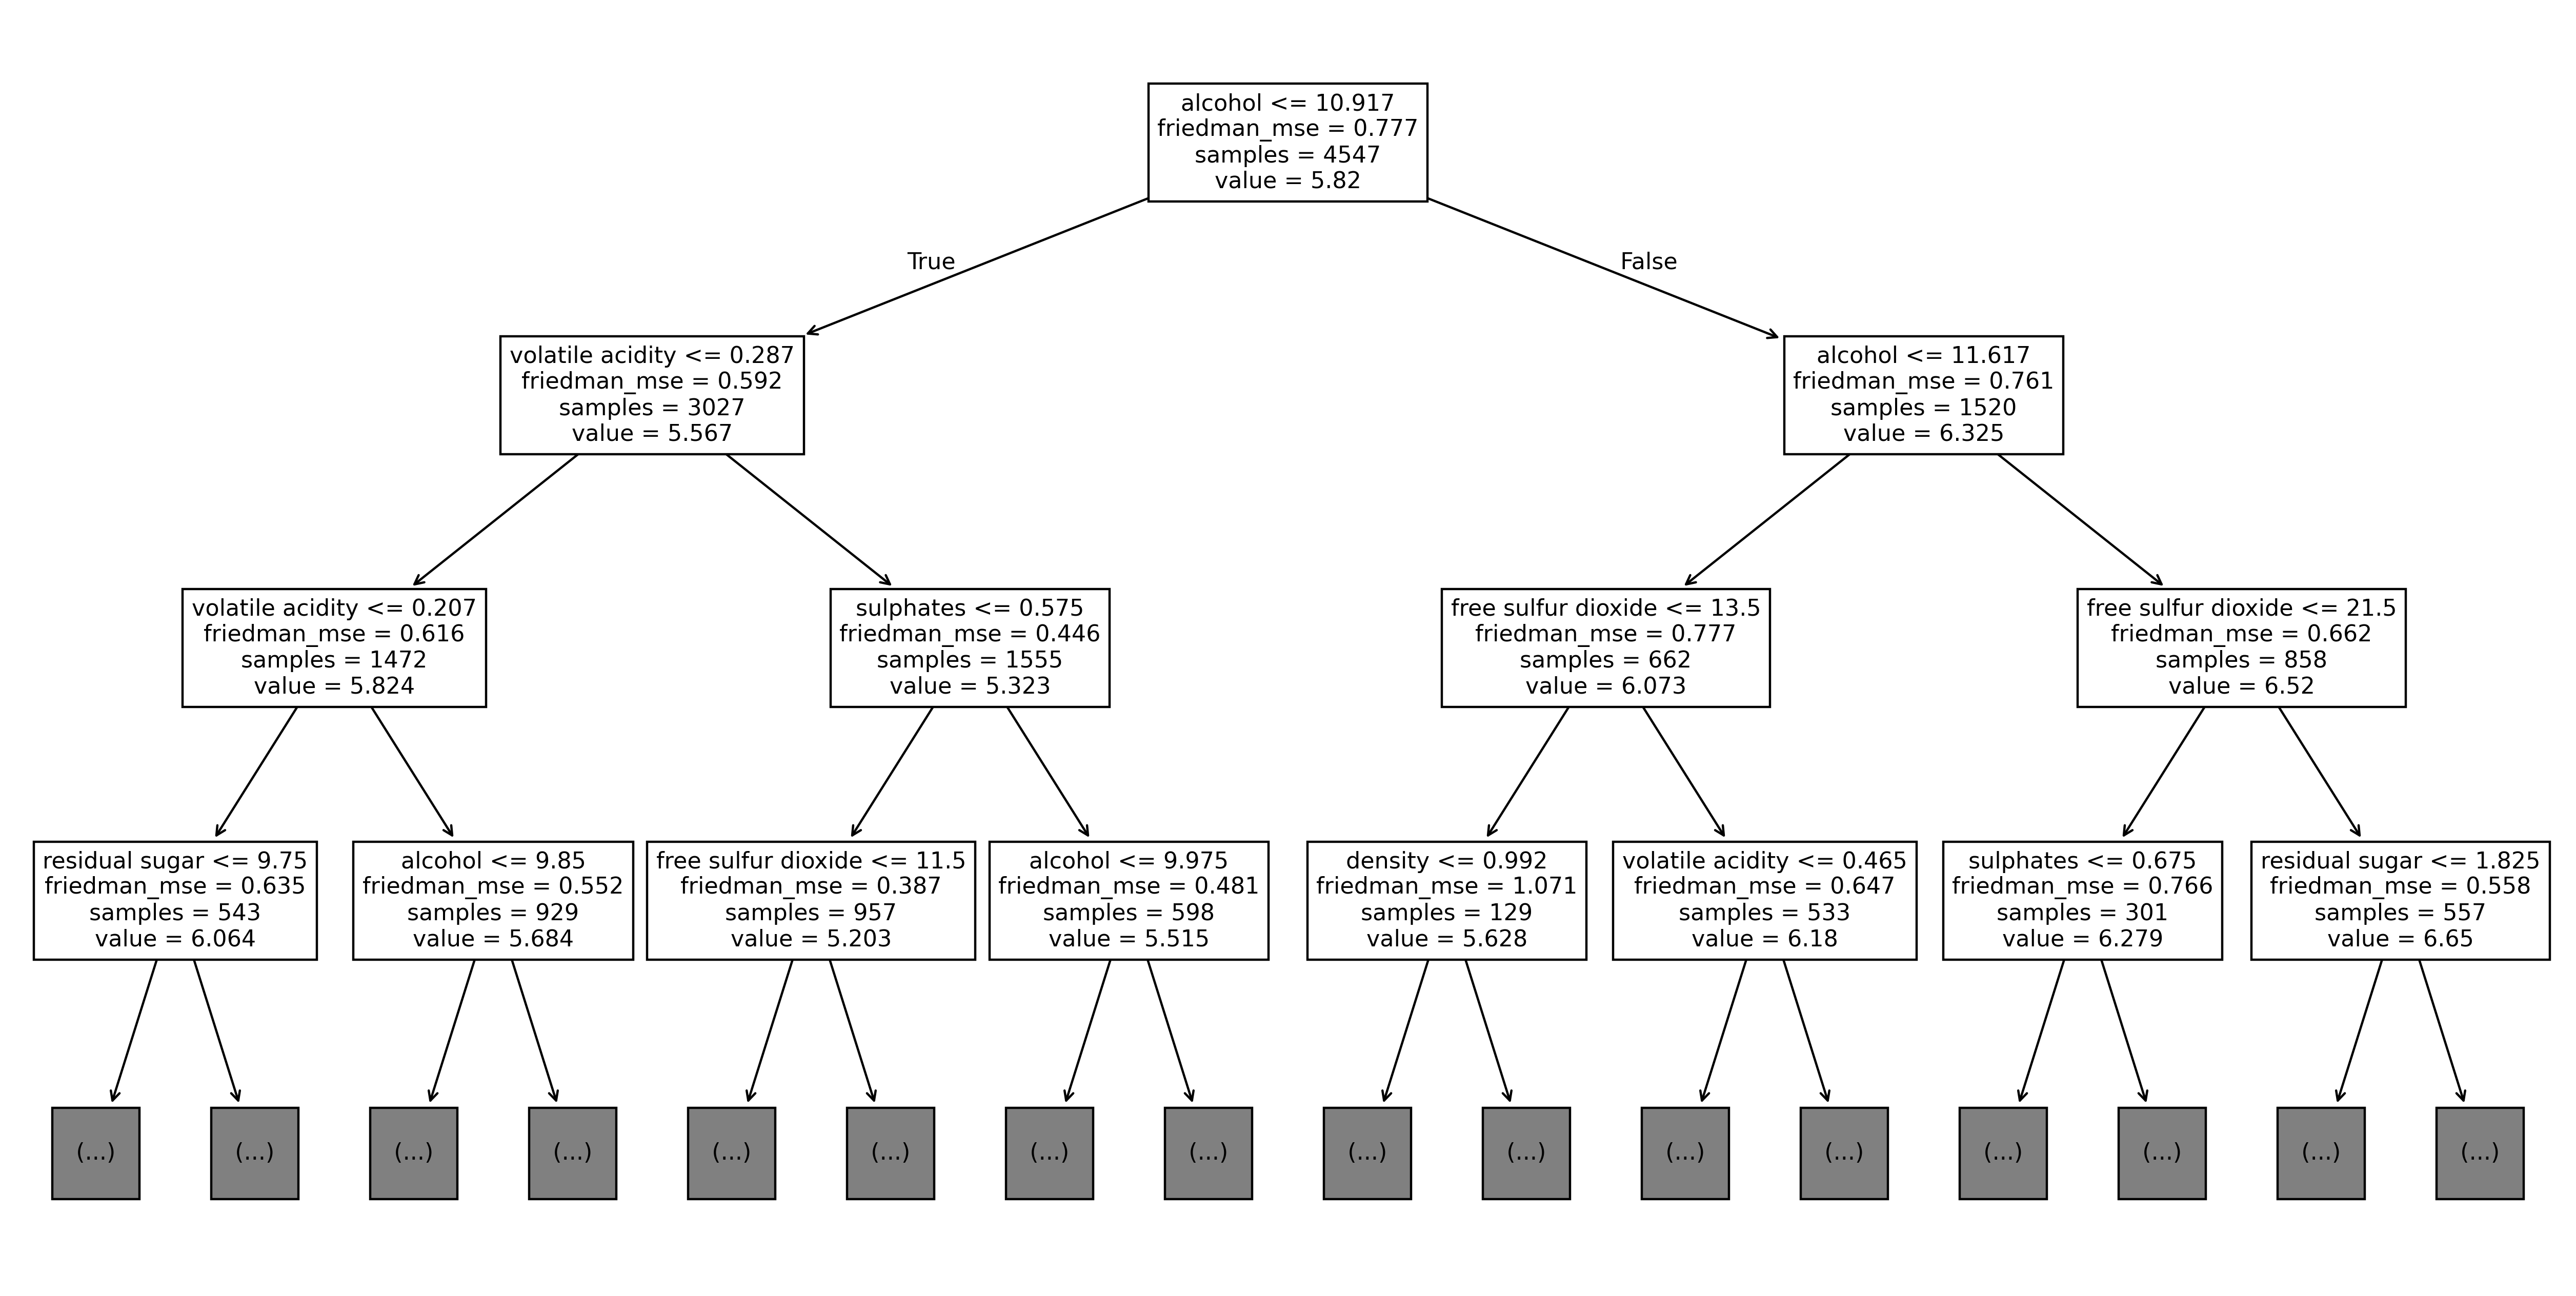

In [35]:
plt.figure(figsize = (20, 10), dpi = 320)

plot_tree(
    best_reg_tree_model,
    max_depth = 3,
    feature_names = X_reg.columns,
    fontsize = 10
)

plt.show()

**Модели ансамблей**

In [ ]:
def objective_ensembles(trial, model_type):
    if model_type in ["BaggingRegressor", "BaggingClassifier"]:
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 10, 50),
            "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
            "max_features": trial.suggest_float("max_features", 0.5, 1.0),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        }

        if model_type == "BaggingRegressor":
            base_tree = DecisionTreeRegressor(**study_reg.best_params, random_state = RANDOM_STATE)
            
            model = BaggingRegressor(estimator = base_tree, **params, random_state = RANDOM_STATE)
            score = cross_val_score(model, X_reg_train, y_reg_train, cv=reg_cv, scoring="neg_mean_squared_error").mean()

        elif model_type == "BaggingClassifier":
            base_tree = DecisionTreeClassifier(**study_class.best_params, random_state=RANDOM_STATE)

            model = BaggingClassifier(estimator=base_tree, **params, random_state=RANDOM_STATE)
            score = cross_val_score(model, X_class_train, y_class_train, cv=class_cv, scoring="accuracy").mean()

    elif model_type in ["GradientBoostingRegressor", "GradientBoostingClassifier"]:
        params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=False),
            "n_estimators": trial.suggest_int("n_estimators", 50, 800, step=50),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "max_features": trial.suggest_categorical("max_features", ['sqrt', 'log2']),
            "n_iter_no_change": 10,
            "validation_fraction": 0.1,
        }

        if model_type == "GradientBoostingRegressor":
            params["loss"] = trial.suggest_categorical("loss", ['squared_error', 'absolute_error', 'huber', 'quantile'])

            model = GradientBoostingRegressor(**params, random_state=RANDOM_STATE)
            score = cross_val_score(model, X_reg_train, y_reg_train, cv=reg_cv, scoring="neg_mean_squared_error").mean()

        elif model_type == "GradientBoostingClassifier":
            params["loss"] = "log_loss"

            model = GradientBoostingClassifier(**params, random_state=RANDOM_STATE)
            score = cross_val_score(model, X_class_train, y_class_train, cv=class_cv, scoring="accuracy").mean()

    elif model_type in ["StackingRegressor", "StackingClassifier"]:
        params = {

        }

        if model_type == "StackingRegressor":
            
            model = StackingRegressor(**params)
            score = cross_val_score(model, X_reg_train, y_reg_train, cv=reg_cv, scoring="neg_mean_squared_error").mean()

        if model_type == "StackingClassifier":

            model = StackingClassifier(**params)
            score = cross_val_score(model, X_class_train, y_class_train, cv=class_cv, scoring="accuracy").mean()

    return score